In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [47]:
df = pd.read_csv('../data/processed/gurgaon_property_cleaned.csv')

In [48]:
df.drop(columns=['Unnamed: 0'] , inplace=True)

In [49]:
df.head()

,Unnamed: 0.1,property_type,sector,society,price,bedRoom,bathroom,balcony,additionalRoom,agePossession,area_type,area_sqm,build_up,area_unit,built_up_area,luxury_category,bhk,floor_cat
0,0,flat,sector 49,breez global hill view,0.35,2,2,2,not_available,0-1 Years Old,NaN,51.48,554.125572,sq.m.,616.0,Unfurnished,2,higher
1,1,flat,sector 49,hcbs sports ville,0.38,2,2,2,not_available,1-5 Years Old,Carpet area: 650 sq.ft. (60.39 sq.m.),69.68,750.028552,sq.m.,750.0,Basic,2,higher
2,2,flat,sector 92,sare crescent parc,0.49,2,2,2,not_available,1-5 Years Old,NaN,92.72,998.028808,sq.m.,1109.0,Unfurnished,2,lower
3,3,flat,sector 89,greenopolis,0.80,2,3,3,"study room,others",Under Construction,NaN,154.22,1660.008658,sq.m.,1660.0,Unfurnished,2,middle
4,4,flat,sector 49,godrej nature plus,1.55,3,2,3+,not_available,Upcoming,NaN,144.65,1556.998135,sq.m.,1730.0,Unfurnished,3,middle


In [50]:
df.shape

(3215, 18)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3215 entries, 0 to 3214
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0.1     3215 non-null   int64  
 1   property_type    3215 non-null   object 
 2   sector           3215 non-null   object 
 3   society          3215 non-null   object 
 4   price            3215 non-null   float64
 5   bedRoom          3215 non-null   int64  
 6   bathroom         3215 non-null   int64  
 7   balcony          3215 non-null   object 
 8   additionalRoom   3215 non-null   object 
 9   agePossession    3215 non-null   object 
 10  area_type        1272 non-null   object 
 11  area_sqm         3188 non-null   float64
 12  build_up         3188 non-null   float64
 13  area_unit        3196 non-null   object 
 14  built_up_area    3215 non-null   float64
 15  luxury_category  3215 non-null   object 
 16  bhk              3215 non-null   int64  
 17  floor_cat     

In [52]:
df[df.duplicated()]

,Unnamed: 0.1,property_type,sector,society,price,bedRoom,bathroom,balcony,additionalRoom,agePossession,area_type,area_sqm,build_up,area_unit,built_up_area,luxury_category,bhk,floor_cat


In [53]:
df.drop_duplicates(inplace=True) # Drop the duplicate rows

In [54]:
df.isnull().sum()

Unnamed: 0.1          0
property_type         0
sector                0
society               0
price                 0
bedRoom               0
bathroom              0
balcony               0
additionalRoom        0
agePossession         0
area_type          1943
area_sqm             27
build_up             27
area_unit            19
built_up_area         0
luxury_category       0
bhk                   0
floor_cat             0
dtype: int64

# Gurgaon Property Price Prediction

## Exploratory Data Analysis (EDA)

### 1. Import Libraries

### 2. Load Dataset

### 3. Dataset Overview
- Dataset Shape
- First Few Rows
- Dataset Information
- Statistical Summary

### 4. Data Quality Analysis
- Missing Values
- Duplicate Values
- Unique Values
- Invalid Values
- Data Type Validation

### 5. Univariate Analysis
- Price Distribution
- Area Distribution
- BHK Distribution
- Bathroom Distribution
- Property Type Distribution
- Sector Distribution
- Society Distribution
- Luxury Category Distribution
- Floor Category Distribution

### 6. Bivariate Analysis
- Price vs Area
- Price vs BHK
- Price vs Bathroom
- Price vs Sector
- Price vs Society
- Price vs Luxury Category

### 7. Multivariate Analysis
- Correlation Analysis
- Multiple Feature Relationships

### 8. Outlier Analysis
- Price Outliers
- Area Outliers
- Other Numerical Outliers

### 9. Feature Engineering

### 10. Feature Selection

### 11. Machine Learning Preparation
- Separate Features and Target
- Train-Test Split
- Numerical Features
- Categorical Features
- Preprocessing

# Univariate Analysis

In [55]:
df['price'].describe()

count    3215.000000
mean        1.920843
std         1.881954
min         0.160000
25%         0.900000
50%         1.400000
75%         2.200000
max        19.000000
Name: price, dtype: float64

In [56]:
df['price'].skew() # this data price columns right skewed

np.float64(3.4174383062304985)

<Axes: xlabel='price', ylabel='Count'>

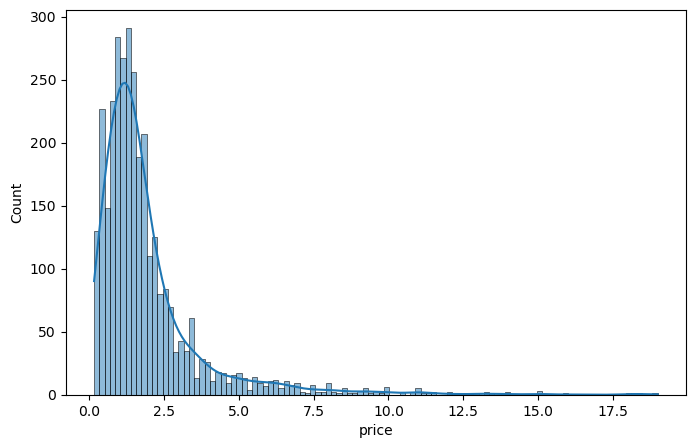

In [57]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'] , kde=True)

<Axes: xlabel='price'>

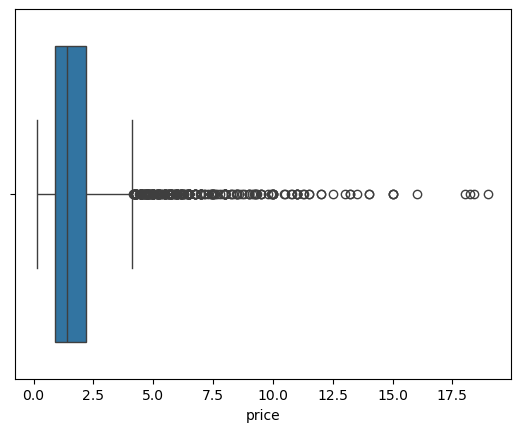

In [58]:
sns.boxplot(x=df['price'])

In [59]:
Q1 = df['price'].quantile(0.25)
Q2 = df['price'].quantile(0.75)

IQR = Q2 - Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q2 = 1.5*IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1.0500000000000003
Upper Bound: 1.9500000000000004


In [60]:
outliers = df[
    (df['price'] < lower_bound) |
    (df['price'] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 966


In [61]:
outliers[['price', 'built_up_area', 'bhk', 'sector', 'society']].head(20)

,price,built_up_area,bhk,sector,society
5,3.60,2809.00,4,sector 60,ireo skyon
7,7.00,3900.00,4,sector 82,vatika india next
11,2.15,2149.00,3,sector 102,conscient heritage max
12,2.45,2061.00,3,sector 49,orchid petals
16,4.70,2368.00,6,sector 22,saksham welfare association
17,4.00,2164.00,3,sector 58,ireo the grand arch
23,2.00,2727.00,4,sector 90,dlf new town heights
27,11.00,2700.00,4,sector 50,unitech espace
31,3.46,2872.00,4,sector 81,dlf the ultima
32,4.78,2500.00,3,sector 22,ambience creacions


In [62]:
df['log_price'] = np.log1p(df['price'])

<Axes: xlabel='log_price', ylabel='Count'>

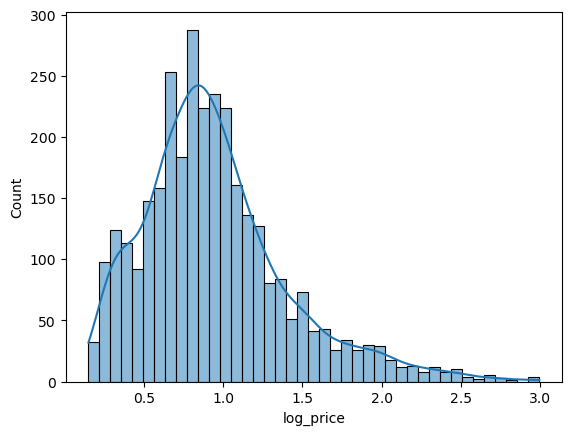

In [63]:
sns.histplot(df['log_price'], kde=True)

In [64]:
print("Original:", df['price'].skew())
print("Log:", df['log_price'].skew())

Original: 3.4174383062304985
Log: 1.0449804454692884


## Area Distribution Univariate 

In [65]:
df['built_up_area'].describe()

count     3215.000000
mean      1815.775365
std       1098.107582
min         30.000000
25%       1258.500000
50%       1650.000000
75%       2160.500000
max      12222.000000
Name: built_up_area, dtype: float64

In [66]:
df['built_up_area'].skew()

np.float64(2.893773941237873)

<Axes: xlabel='built_up_area', ylabel='Count'>

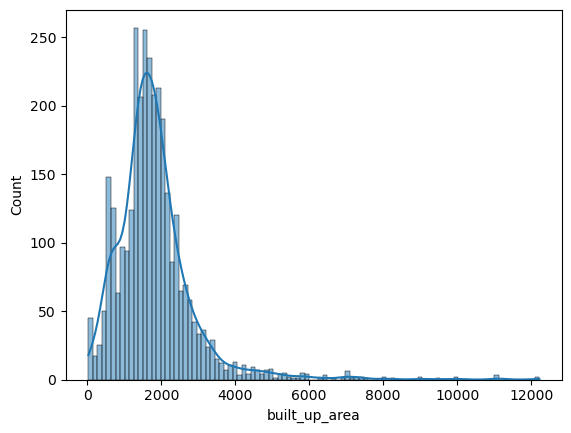

In [67]:
sns.histplot(df['built_up_area'], kde=True)

<Axes: xlabel='built_up_area'>

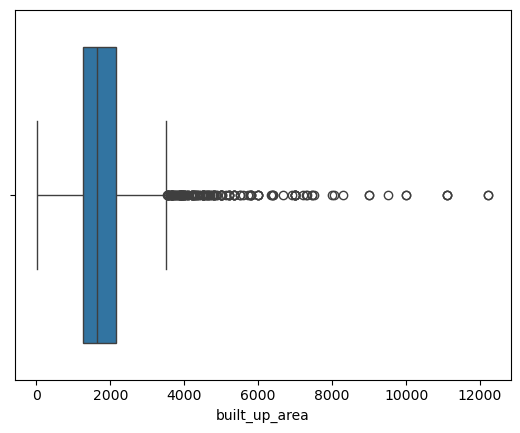

In [68]:
sns.boxplot(x=df['built_up_area'])

In [69]:
df = df[df['built_up_area'] < 9000]

<Axes: xlabel='built_up_area'>

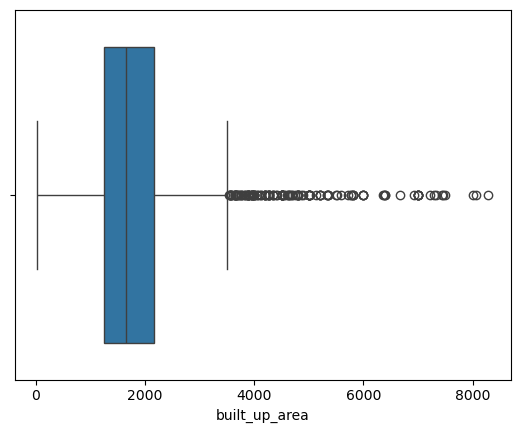

In [70]:
sns.boxplot(x=df['built_up_area'])

In [71]:
Q1 = df['built_up_area'].quantile(0.25)
Q3 = df['built_up_area'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -98.5
Upper Bound: 3513.5


In [72]:
area_outliers = df[
    (df['built_up_area'] < lower_bound) |
    (df['built_up_area'] > upper_bound)
]


In [73]:
area_outliers[
    ['built_up_area', 'price', 'bhk', 'sector', 'society']
].head(20)

,built_up_area,price,bhk,sector,society
7,3900.00,7.00,4,sector 82,vatika india next
10,3569.00,0.17,1,sector 95,ramsons kshitij
42,6000.00,5.35,4,sector 70a,bptp visionnaire
53,3573.33,5.31,4,sector 112,experion windchants
65,6382.00,7.99,4,sector 112,experion windchants
88,6926.00,4.70,4,sector 81,bestech park view grand spa
96,3889.00,1.15,3,sector 105,Rajendra Park
117,4000.00,6.75,4,sector 72,tata primanti
132,5514.00,10.75,5,sector 62,pioneer araya
135,3880.00,4.49,5,sector 110,indiabulls enigma


In [74]:
suspicious_area = df[df['built_up_area'] < 200].copy()

In [75]:
suspicious_area[
    [
        'built_up_area',
        'price',
        'property_type',
        'society',
        'sector',
        'bedRoom',
        'bathroom',
        'bhk'
    ]
].sort_values('built_up_area')

,built_up_area,price,property_type,society,sector,bedRoom,bathroom,bhk
1970,30.00,0.60,house,rk excelo,sector 12,5,3,5
561,37.00,0.22,house,Devilal Colony,sector 9,2,2,2
796,50.00,0.45,house,Gandhi Nagar,sector 28,5,3,5
1078,50.00,0.47,house,Laxman Vihar,sector 4,2,2,2
2252,53.00,0.50,house,Laxman Vihar,sector 4,5,3,5
2883,56.00,0.38,house,Rajendra Park,sector 105,2,2,2
1798,56.00,0.55,house,Rajendra Park,sector 105,4,4,4
2491,60.00,1.90,house,Sushant Lok Phase 1,sector 43,3,3,3
2720,60.00,2.00,house,suncity township,sector 54,9,9,9
110,62.00,1.40,house,sector rwa,sector 38,8,8,8


In [76]:
suspicious = df[
    (df['built_up_area'] < 200) &
    (df['bhk'] >= 4)
]

suspicious[
    ['built_up_area', 'bhk', 'bedRoom',
     'bathroom', 'price', 'society', 'sector']
]

,built_up_area,bhk,bedRoom,bathroom,price,society,sector
56,120.0,5,5,5,1.60,Surya Vihar,sector 21
59,133.0,9,9,4,0.98,Palam Vihar Extension,sector 2
110,62.0,8,8,8,1.40,sector rwa,sector 38
369,190.0,9,9,6,6.00,Jacobpura,sector 12
559,120.0,5,5,5,1.25,Dayanand Colony,sector 6
796,50.0,5,5,3,0.45,Gandhi Nagar,sector 28
1067,122.0,5,5,4,1.16,Jyoti Park,sector 7
1641,173.0,5,5,5,2.80,Ansal Plaza,sector 23
1755,90.0,4,4,3,2.25,Sector 46 Gurgaon,sector 46
1798,56.0,4,4,4,0.55,Rajendra Park,sector 105


In [77]:
df.drop([1970, 796, 2252, 1798, 2720, 110, 1755], inplace=True)
df.reset_index(drop=True, inplace=True)

## BHK distribution


In [78]:
df['bhk'].describe()

count    3198.000000
mean        2.929956
std         1.068547
min         1.000000
25%         2.000000
50%         3.000000
75%         3.000000
max        10.000000
Name: bhk, dtype: float64

<Axes: xlabel='bhk', ylabel='count'>

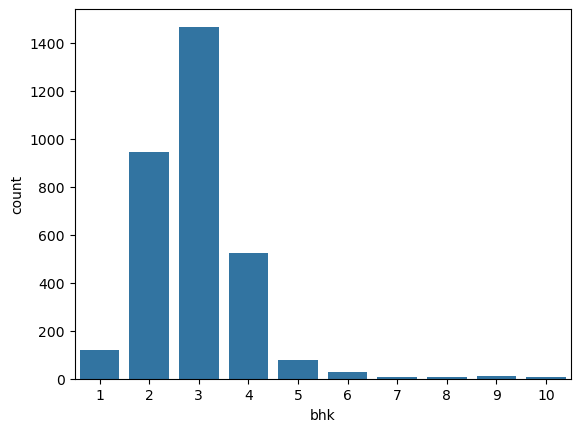

In [79]:
sns.countplot(data=df, x='bhk')

In [80]:
df[df['bhk'] >= 7][
    ['bhk', 'bedRoom', 'bathroom', 'built_up_area', 'price']
]

,bhk,bedRoom,bathroom,built_up_area,price
59,9,9,4,133.0,0.98
237,7,7,5,2367.0,4.75
242,9,9,9,1125.0,5.00
367,9,9,6,190.0,6.00
628,7,7,7,3000.0,2.75
631,8,8,11,5000.0,11.00
691,10,10,10,7500.0,9.35
789,8,8,5,540.0,1.60
806,9,9,9,1494.0,4.30
848,7,7,5,4500.0,11.30


In [81]:
pd.crosstab(df['bhk'], df['bedRoom'])

bedRoom,1,2,3,4,5,6,7,8,9,10
bhk,,,,,,,,,,
1,119,0,0,0,0,0,0,0,0,0
2,0,946,0,0,0,0,0,0,0,0
3,0,0,1468,0,0,0,0,0,0,0
4,0,0,0,525,0,0,0,0,0,0
5,0,0,0,0,79,0,0,0,0,0
6,0,0,0,0,0,26,0,0,0,0
7,0,0,0,0,0,0,6,0,0,0
8,0,0,0,0,0,0,0,8,0,0
9,0,0,0,0,0,0,0,0,12,0


<Axes: xlabel='bhk', ylabel='built_up_area'>

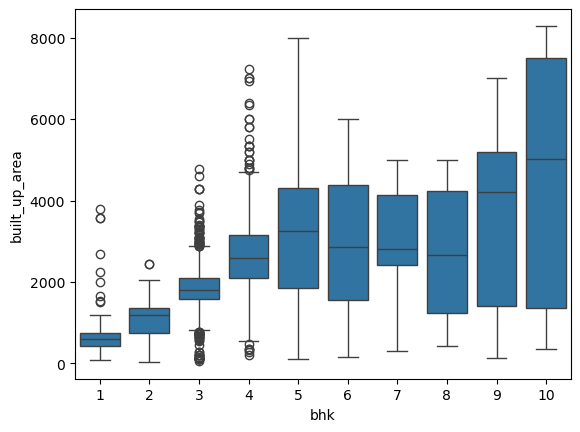

In [83]:
sns.boxplot(
    data=df,
    x='bhk',
    y='built_up_area'
)


## bathroom

In [84]:
df['bathroom'].describe()

count    3198.000000
mean        3.044090
std         1.220816
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        12.000000
Name: bathroom, dtype: float64

<Axes: xlabel='bathroom', ylabel='count'>

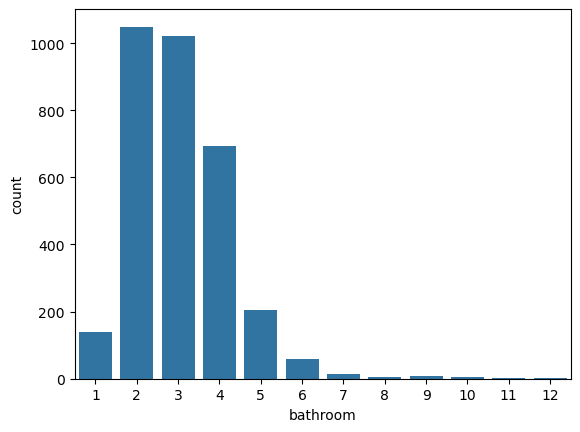

In [85]:
sns.countplot(data=df, x='bathroom')

In [90]:
df[df['bathroom'] >= 7][
    ['bathroom', 'bhk', 'bedRoom', 'built_up_area', 'price']
].sort_values('bathroom', ascending=False)

,bathroom,bhk,bedRoom,built_up_area,price
1696,12,9,9,6390.0,18.02
631,11,8,8,5000.0,11.00
999,11,10,10,7000.0,7.00
1969,10,10,10,347.0,8.00
976,10,10,10,400.0,2.25
2037,10,8,8,435.0,10.00
1028,10,10,10,8056.0,13.00
691,10,10,10,7500.0,9.35
3053,10,10,10,8286.0,8.00
806,9,9,9,1494.0,4.30


In [91]:
pd.crosstab(df['bhk'], df['bathroom'])

bathroom,1,2,3,4,5,6,7,8,9,10,11,12
bhk,,,,,,,,,,,,
1,109,10,0,0,0,0,0,0,0,0,0,0
2,18,883,44,1,0,0,0,0,0,0,0,0
3,7,152,909,360,40,0,0,0,0,0,0,0
4,2,3,57,308,121,34,0,0,0,0,0,0
5,1,0,9,16,34,14,5,0,0,0,0,0
6,1,1,0,7,5,9,3,0,0,0,0,0
7,0,0,1,0,2,0,3,0,0,0,0,0
8,0,0,0,0,2,0,1,3,0,1,1,0
9,0,0,0,1,0,1,1,0,8,0,0,1


## Sector

In [96]:
df['sector'].value_counts()

sector
sector 49     246
sector 102    113
sector 85     109
sector 92     105
sector 69      93
             ... 
sector 45       2
sector 37       1
sector 46       1
sector 40       1
sector 26       1
Name: count, Length: 107, dtype: int64

## society

In [97]:
df['society'].value_counts()

society
tulip violet                            75
ss the leaf                             74
shapoorji pallonji joyville gurugram    45
dlf new town heights                    39
signature global park                   37
                                        ..
bptp park generations                    1
Gandhi Nagar                             1
takshila heights sector 37 c             1
ansal plaza                              1
sonata group housing gh 24               1
Name: count, Length: 696, dtype: int64

# luxury category

In [100]:
df['luxury_category'].value_counts()

luxury_category
Premium        1304
Unfurnished    1202
Basic           306
Semi-Luxury     197
Luxury          189
Name: count, dtype: int64

<Axes: ylabel='count'>

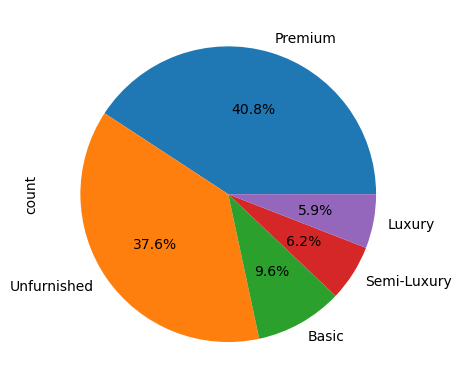

In [101]:
df['luxury_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

## Floor catogory

In [102]:
df.head(1)

,Unnamed: 0.1,property_type,sector,society,price,bedRoom,bathroom,balcony,additionalRoom,agePossession,area_type,area_sqm,build_up,area_unit,built_up_area,luxury_category,bhk,floor_cat,log_price
0,0,flat,sector 49,breez global hill view,0.35,2,2,2,not_available,0-1 Years Old,NaN,51.48,554.125572,sq.m.,616.0,Unfurnished,2,higher,0.300105


In [103]:
df['floor_cat'].value_counts()

floor_cat
lower     1289
higher    1176
middle     733
Name: count, dtype: int64

<Axes: ylabel='count'>

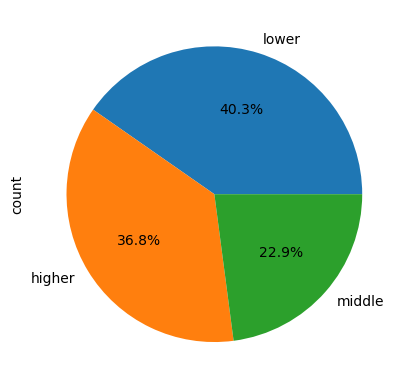

In [104]:
df['floor_cat'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

# Bivariate Analysis

##Price vs Area


<Axes: xlabel='price', ylabel='built_up_area'>

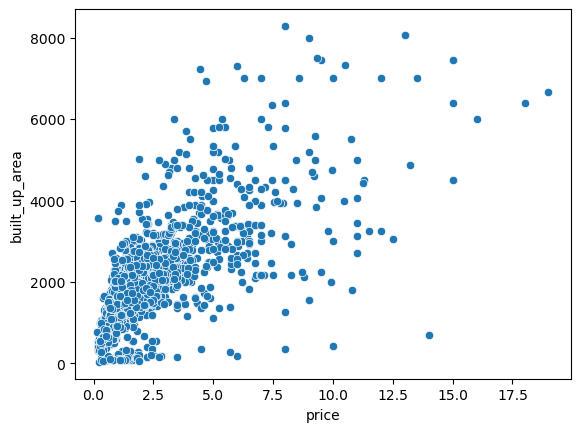

In [108]:
plt.Figure(figsize=(10,6))
sns.scatterplot(x=df['price'] , y=df['built_up_area'])

<Axes: xlabel='built_up_area', ylabel='price'>

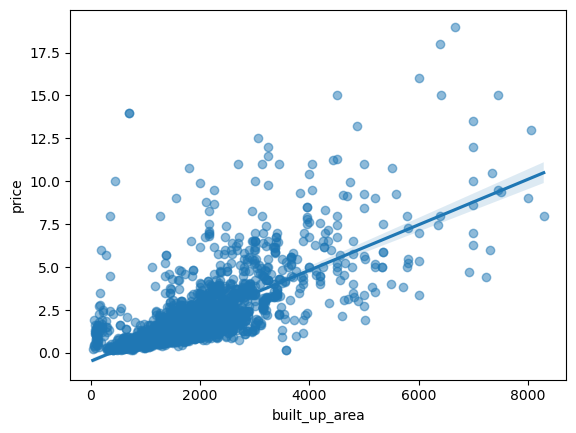

In [109]:
sns.regplot(
    data=df,
    x='built_up_area',
    y='price',
    scatter_kws={'alpha': 0.5}
)

In [110]:
df[['built_up_area', 'price']].corr()

,built_up_area,price
built_up_area,1.000000,0.721595
price,0.721595,1.000000


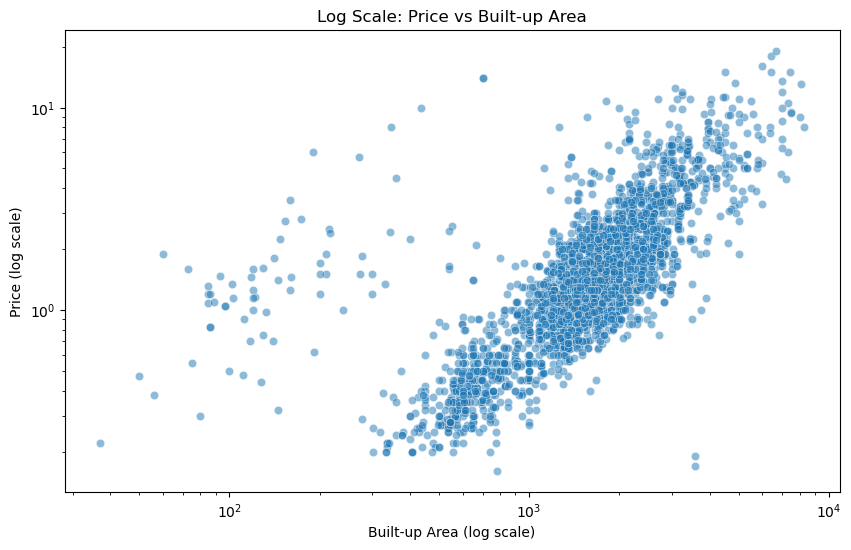

In [111]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='built_up_area',
    y='price',
    alpha=0.5
)

plt.xscale('log')
plt.yscale('log')

plt.title('Log Scale: Price vs Built-up Area')
plt.xlabel('Built-up Area (log scale)')
plt.ylabel('Price (log scale)')

plt.show()


# price vs BHK

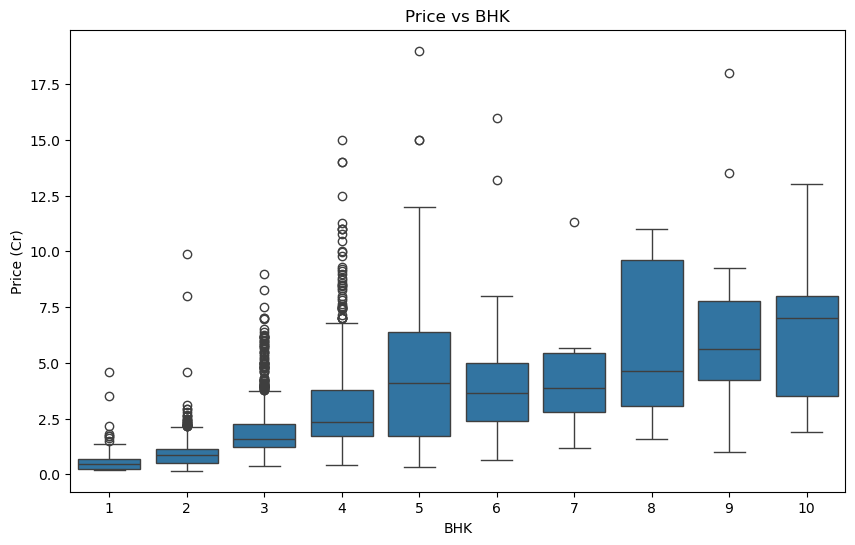

In [115]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='bhk',
    y='price'
)

plt.title('Price vs BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Cr)')

plt.show()

## price vs bathroom

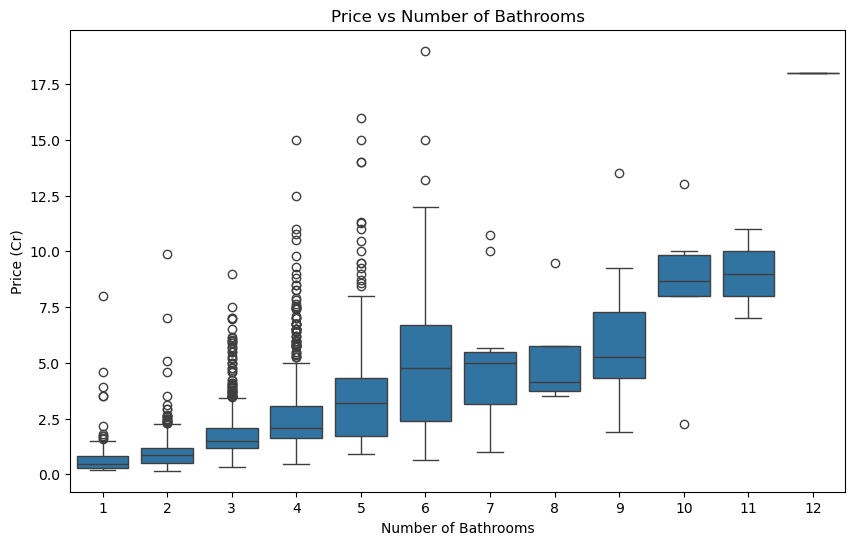

In [116]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='bathroom',
    y='price'
)

plt.title('Price vs Number of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price (Cr)')

plt.show()

## Price vs Sector

In [117]:
top_sectors = df['sector'].value_counts().head(15).index

top_sectors

Index(['sector 49', 'sector 102', 'sector 85', 'sector 92', 'sector 69',
       'sector 90', 'sector 65', 'sector 81', 'sector 79', 'sector 104',
       'sector 83', 'sector 37d', 'sector 89', 'sector 86', 'sector 95'],
      dtype='object', name='sector')

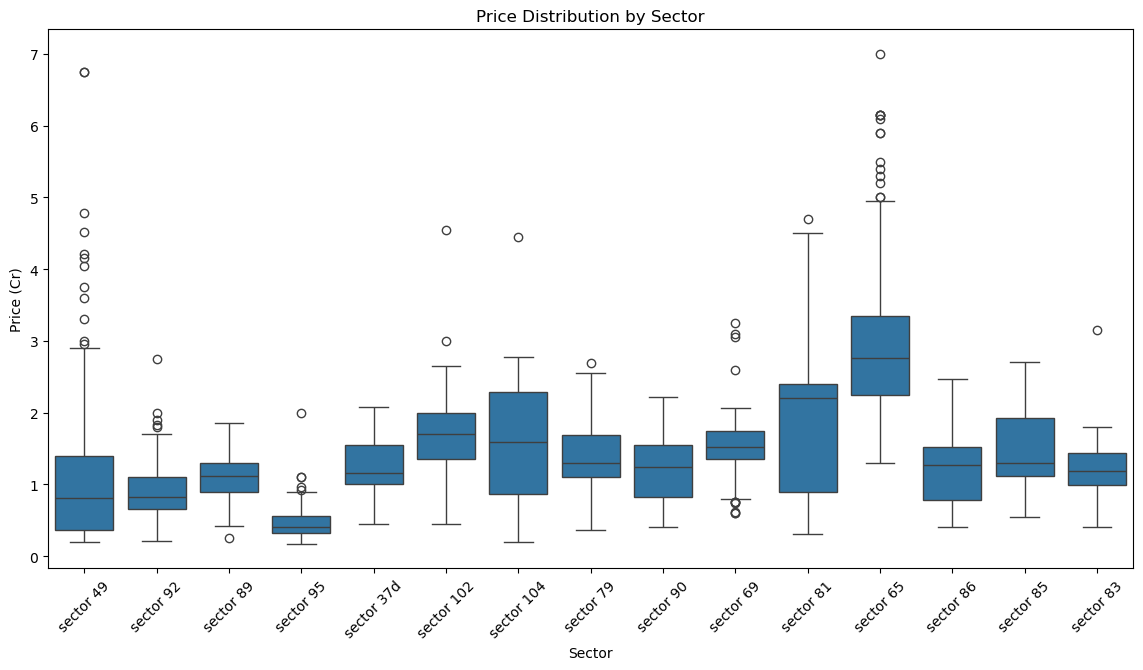

In [118]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df[df['sector'].isin(top_sectors)],
    x='sector',
    y='price'
)

plt.title('Price Distribution by Sector')
plt.xlabel('Sector')
plt.ylabel('Price (Cr)')

plt.xticks(rotation=45)

plt.show()

In [119]:
sector_avg_price = (
    df[df['sector'].isin(top_sectors)]
    .groupby('sector')['price']
    .mean()
    .sort_values(ascending=False)
)

print(sector_avg_price)

sector
sector 65     3.111364
sector 81     1.916250
sector 102    1.681327
sector 104    1.569143
sector 69     1.544731
sector 85     1.490734
sector 79     1.377125
sector 83     1.247794
sector 37d    1.230303
sector 90     1.200989
sector 86     1.161270
sector 89     1.117031
sector 49     1.109350
sector 92     0.925905
sector 95     0.486610
Name: price, dtype: float64


## price vs society

In [120]:
top_societies = df['society'].value_counts().head(15).index

In [121]:
society_avg_price = (
    df[df['society'].isin(top_societies)]
    .groupby('society')['price']
    .mean()
    .sort_values(ascending=False)
)

print(society_avg_price)

society
emaar mgf emerald floors premier        2.592500
dlf the ultima                          2.498710
la vida by tata housing                 2.290000
smart world orchard                     1.952813
tulip violet                            1.627867
shree vardhman victoria                 1.572571
shapoorji pallonji joyville gurugram    1.564222
ss the leaf                             1.556892
dlf new town heights                    1.545385
dlf regal gardens                       1.413333
paras dews                              1.199032
m3m woodshire                           1.160000
smart world gems                        1.082727
shree vardhman flora                    0.835517
signature global park                   0.696757
Name: price, dtype: float64


## Price vs Luxury Category

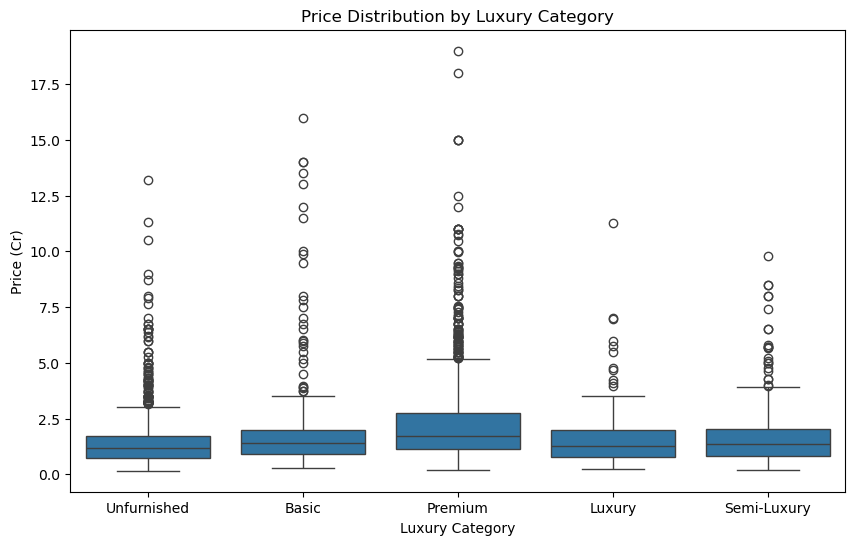

In [123]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='luxury_category',
    y='price'
)

plt.title('Price Distribution by Luxury Category')
plt.xlabel('Luxury Category')
plt.ylabel('Price (Cr)')

plt.show()

In [125]:
df.groupby('luxury_category')['price'].mean().sort_values(ascending=False)

luxury_category
Premium        2.311005
Basic          2.048529
Semi-Luxury    1.856091
Luxury         1.615132
Unfurnished    1.453494
Name: price, dtype: float64

# Multivariate Analysis

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3198 entries, 0 to 3197
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0.1     3198 non-null   int64  
 1   property_type    3198 non-null   object 
 2   sector           3198 non-null   object 
 3   society          3198 non-null   object 
 4   price            3198 non-null   float64
 5   bedRoom          3198 non-null   int64  
 6   bathroom         3198 non-null   int64  
 7   balcony          3198 non-null   object 
 8   additionalRoom   3198 non-null   object 
 9   agePossession    3198 non-null   object 
 10  area_type        1264 non-null   object 
 11  area_sqm         3172 non-null   float64
 12  build_up         3172 non-null   float64
 13  area_unit        3179 non-null   object 
 14  built_up_area    3198 non-null   float64
 15  luxury_category  3198 non-null   object 
 16  bhk              3198 non-null   int64  
 17  floor_cat     

In [130]:
num_cols = [
    'price',
    'built_up_area',
    'bedRoom',
    'bhk',
    'bathroom'
]

corr = df[num_cols].corr()

corr

,price,built_up_area,bedRoom,bhk,bathroom
price,1.000000,0.721595,0.558190,0.558190,0.604028
built_up_area,0.721595,1.000000,0.623202,0.623202,0.689093
bedRoom,0.558190,0.623202,1.000000,1.000000,0.835365
bhk,0.558190,0.623202,1.000000,1.000000,0.835365
bathroom,0.604028,0.689093,0.835365,0.835365,1.000000


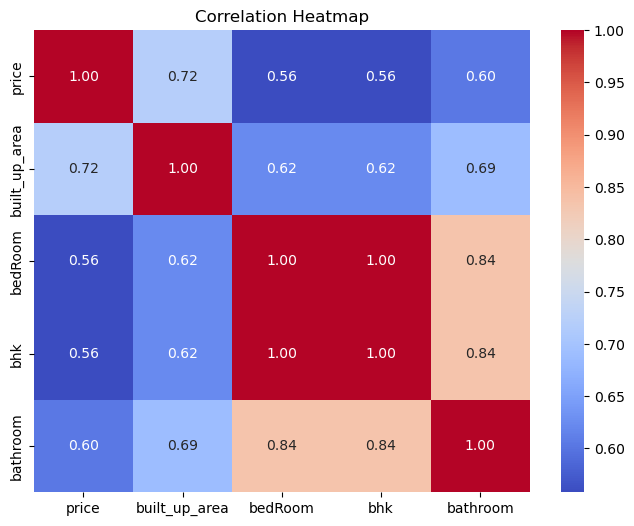

In [131]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# Multiple Feature Relationships

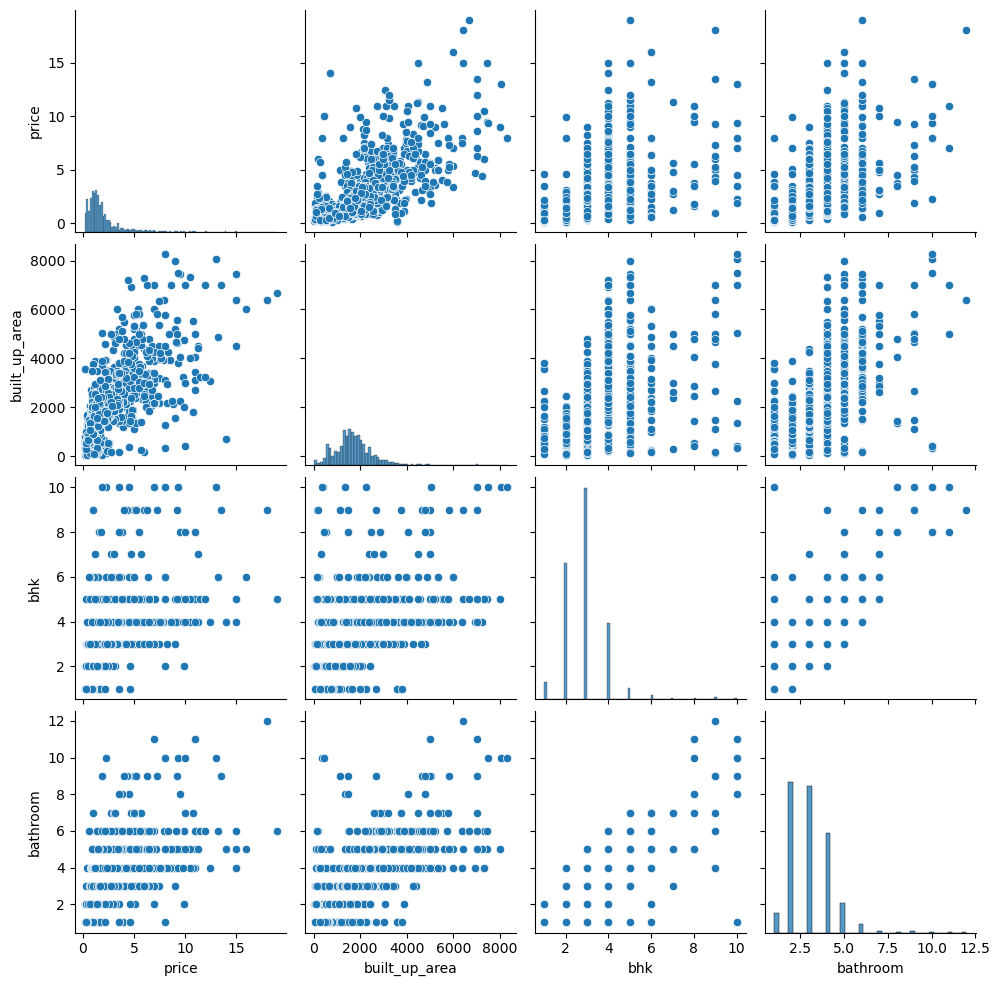

In [132]:
features = [
    'price',
    'built_up_area',
    'bhk',
    'bathroom'
]

sns.pairplot(df[features])

plt.show()

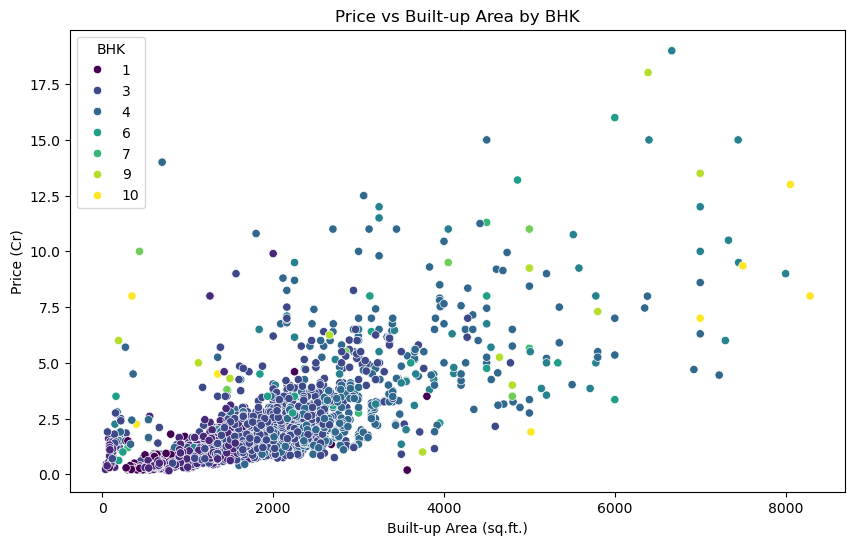

In [133]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='built_up_area',
    y='price',
    hue='bhk',
    palette='viridis'
)

plt.title('Price vs Built-up Area by BHK')
plt.xlabel('Built-up Area (sq.ft.)')
plt.ylabel('Price (Cr)')
plt.legend(title='BHK')

plt.show()

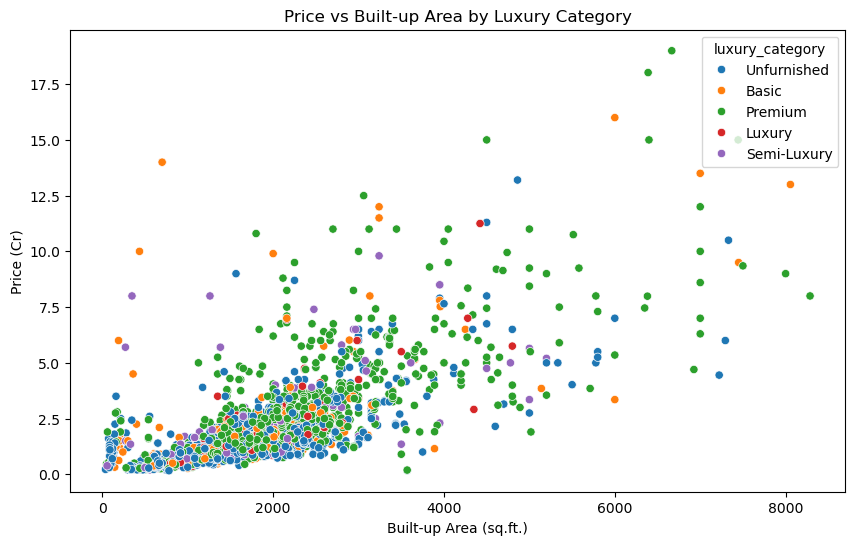

In [135]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='built_up_area',
    y='price',
    hue='luxury_category'
)

plt.title('Price vs Built-up Area by Luxury Category')
plt.xlabel('Built-up Area (sq.ft.)')
plt.ylabel('Price (Cr)')

plt.show()

<Axes: xlabel='built_up_area', ylabel='price'>

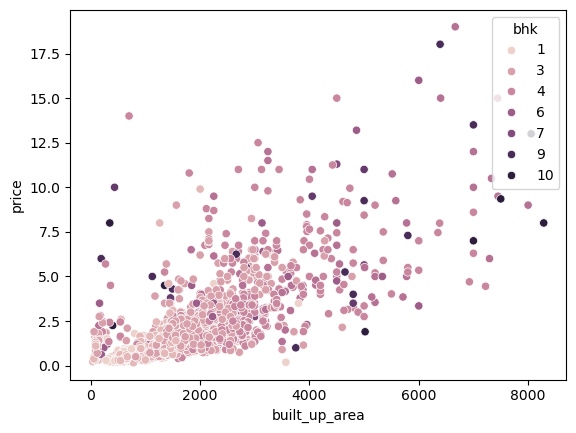

In [137]:
sns.scatterplot(
    data=df,
    x='built_up_area',
    y='price',
    hue='bhk'
)

<Axes: xlabel='built_up_area', ylabel='price'>

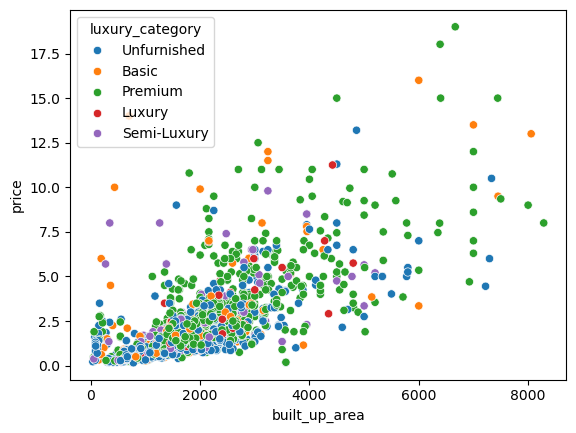

In [139]:
sns.scatterplot(
    data=df,
    x='built_up_area',
    y='price',
    hue='luxury_category'
)